# CityMesh simulation video
Cell 1 is the simulation model. Cell 2 draws the animation and saves `citymesh_simulation.mp4` (needs `ffmpeg`; without it a GIF is saved).

In [1]:
# ---- CityMesh simulation model (analytical). Parameters are representative values, not measurements.
import math

TECHS = ['lora', 'nbiot', 'zigbee', 'wifi6', 'g5', 'sat']
TECH = {
    'lora':   dict(name='LoRaWAN',       color='#0f766e', fMHz=866,  module=6,  sub=0,  infraCapex=1200, infraOpex=300, infraW=10),
    'nbiot':  dict(name='NB-IoT',        color='#1d4ed8', fMHz=900,  module=7,  sub=5,  budget=164),
    'zigbee': dict(name='ZigBee',        color='#a16207', fMHz=2440, module=4,  sub=0,  budget=108, infraCapex=150, infraOpex=60, infraW=3, hops=4, rateKbps=250),
    'wifi6':  dict(name='Wi-Fi 6',       color='#7c3aed', fMHz=2440, module=5,  sub=0,  budget=105, infraCapex=400, infraOpex=80, infraW=15, rateKbps=100000),
    'g5':     dict(name='5G',            color='#c2410c', fMHz=3500, module=35, sub=30, budget=144, rateKbps=50000),
    'sat':    dict(name='Satellite IoT', color='#475569', fMHz=1600, module=30, sub=30, rateKbps=0.5),
}
LORA_SF = [(7, -123), (8, -126), (9, -129), (10, -132), (11, -134.5), (12, -137)]
# Six device classes: share of devices, wall loss (dB), report interval T (s), requirements, TOPSIS weights
CLASSES = [
    dict(id='A', name='Massive metering and sensing', share=0.55, pen=8,  T=1800,  battery=True,  cluster=0,  sky=0.80, remoteKm=0,
         need=dict(dl=0.90, batt=5, lat=60, tco=100),      w=dict(dl=.25, batt=.25, lat=.05, rate=.05, tco=.25, en=.15)),
    dict(id='B', name='Deep-indoor and underground',  share=0.15, pen=25, T=21600, battery=True,  cluster=0,  sky=0.0,  remoteKm=0,
         need=dict(dl=0.90, batt=5, tco=150),              w=dict(dl=.40, batt=.20, lat=.05, rate=0,   tco=.20, en=.15)),
    dict(id='C', name='Dense local clusters',         share=0.17, pen=12, T=60,    battery=False, cluster=40, sky=0.30, remoteKm=0,
         need=dict(dl=0.95, lat=1, rate=20, tco=100),      w=dict(dl=.25, batt=0,   lat=.20, rate=.05, tco=.30, en=.20)),
    dict(id='D', name='Critical wide-area control',   share=0.03, pen=0,  T=1,     battery=False, cluster=0,  sky=0.80, remoteKm=0,
         need=dict(dl=0.97, lat=0.05, rate=1000, tco=600), w=dict(dl=.30, batt=0,   lat=.30, rate=.30, tco=.10, en=0)),
    dict(id='E', name='High-rate edge sites',         share=0.05, pen=5,  T=1,     battery=False, cluster=30, sky=0.50, remoteKm=0,
         need=dict(dl=0.97, lat=0.05, rate=2000, tco=150), w=dict(dl=.20, batt=0,   lat=.20, rate=.30, tco=.30, en=0)),
    dict(id='F', name='Remote and disaster fallback', share=0.05, pen=0,  T=3600,  battery=True,  cluster=0,  sky=0.95, remoteKm=30,
         need=dict(dl=0.85, batt=2, tco=500),              w=dict(dl=.45, batt=.20, lat=.05, rate=0,   tco=.20, en=.10)),
]
DEFAULTS = dict(areaKm2=400, nodes=100000, n=3.5, sigma=8, payload=20, loraGw=120, loraChannels=8,
                isdNb=1.0, isd5g=0.5, battmAh=3600, years=10, outage=0.05, backupShare=0.3)

def Q(x):                                   # Gaussian tail probability
    t = 1 / (1 + 0.2316419 * abs(x)); d = 0.3989423 * math.exp(-x * x / 2)
    p = d * t * (0.3193815 + t * (-0.3565638 + t * (1.781478 + t * (-1.821256 + t * 1.330274))))
    return p if x >= 0 else 1 - p

def path_loss(d_km, f_mhz, n):              # log-distance model, 1 m reference
    return 20 * math.log10(f_mhz) - 27.55 + 10 * n * math.log10(max(d_km, 0.001) * 1000)

def range_km(budget, f_mhz, n):             # distance at which the loss equals the link budget
    return 10 ** ((budget - (20 * math.log10(f_mhz) - 27.55)) / (10 * n)) / 1000

def cell_coverage(budget, f_mhz, n, sigma, pen, Rc, steps=60):   # share of a cell with a working link
    s = 0
    for i in range(steps):
        r = (i + 0.5) / steps * Rc
        s += Q((path_loss(r, f_mhz, n) + pen - budget) / sigma) * 2 * r / (Rc * Rc) * (Rc / steps)
    return min(1, s)

def lora_airtime(sf, payload):              # Semtech AN1200.13
    tsym = 2 ** sf / 125000; de = 1 if sf >= 11 else 0
    n_pay = 8 + max(math.ceil((8 * (payload + 13) - 4 * sf + 44) / (4 * (sf - 2 * de))) * 5, 0)
    return (12.25 + n_pay) * tsym

def batt_years(avg_mA, p):
    return min(15, p['battmAh'] * 0.85 / avg_mA / 8760)

def eval_tech(tk, c, p, lora_load):
    """Delivery, battery life, latency, data rate, cost and feasibility of one technology for one class."""
    t = TECH[tk]; N = p['nodes'] * c['share']; o = dict(tech=tk, duty_fail=False)
    n = 3.0 if c['remoteKm'] else p['n']
    infra_per_dev = infra_w = 0
    if tk == 'lora':
        Rc = math.sqrt(p['areaKm2'] / p['loraGw'] / 2.598); gain = 5; b_max = 14 + gain + 137
        if c['remoteKm']:
            cov = Q((path_loss(c['remoteKm'], t['fMHz'], n) - b_max) / p['sigma']); mix = [0, 0, 0, 0, 0, 1]
        else:
            cov = cell_coverage(b_max, t['fMHz'], n, p['sigma'], c['pen'], Rc); mix = []; prev = 0
            for i, (sf, sens) in enumerate(LORA_SF):          # lowest spreading factor that reaches the device
                r = Rc if i == 5 else min(Rc, range_km(14 + gain - sens - c['pen'], t['fMHz'], n))
                mix.append(max(0, (r * r - prev * prev) / (Rc * Rc))); prev = max(prev, r)
        per_gw = lora_load / p['loraGw']; pdr = toa = rate = duty = 0
        for j, (sf, _) in enumerate(LORA_SF):
            ta = lora_airtime(sf, p['payload'])
            G = per_gw * mix[j] * ta / (1800 * p['loraChannels'])   # pure ALOHA load per SF and channel
            pdr += mix[j] * math.exp(-2 * G); toa += mix[j] * ta
            rate += mix[j] * sf * 125000 / 2 ** sf * 0.8 / 1000
            duty = max(duty, ta / c['T'] if mix[j] > 0.01 else 0)
        o.update(dl=cov * pdr, lat=toa + 0.3, rate=rate, avg_mA=(44 * toa + 11 * 0.3) / c['T'] + 0.003,
                 enJ=3.6 * (0.044 * toa + 0.011 * 0.3), duty_fail=duty > 0.01)
        infra_per_dev = (t['infraCapex'] + t['infraOpex'] * p['years']) * p['loraGw'] / max(1, lora_load)
        infra_w = t['infraW'] * p['loraGw'] / max(1, lora_load)
    elif tk in ('nbiot', 'g5'):
        Rcc = (p['isdNb'] if tk == 'nbiot' else p['isd5g']) / math.sqrt(3)
        cv = (Q((path_loss(c['remoteKm'], t['fMHz'], n) - t['budget']) / p['sigma']) if c['remoteKm']
              else cell_coverage(t['budget'], t['fMHz'], n, p['sigma'], c['pen'], Rcc))
        if tk == 'nbiot':
            deep = c['pen'] >= 20 or c['remoteKm']; ttx, trx = (4, 3) if deep else (0.8, 1.5)
            o.update(dl=cv * 0.99, lat=10 if deep else 4, rate=5 if deep else 60,
                     avg_mA=(220 * ttx + 46 * trx) / c['T'] + 0.005, enJ=3.6 * (0.22 * ttx + 0.046 * trx))
        else:
            o.update(dl=cv * 0.999, lat=0.02, rate=t['rateKbps'], avg_mA=(400 * 0.5 + 100 * 2) / c['T'] + 0.05,
                     enJ=3.6 * (0.4 * 0.5 + 0.1 * 2))
    elif tk in ('zigbee', 'wifi6'):
        if c['remoteKm']:
            o.update(dl=0, lat=99, rate=0, avg_mA=1, enJ=0)
        else:
            zb = tk == 'zigbee'
            r1 = range_km(t['budget'] - c['pen'] - p['sigma'], t['fMHz'], n)
            r_eff = r1 * (0.7 * t['hops'] if zb else 1)
            per_unit = c['cluster'] if c['cluster'] else max(1, (N / p['areaKm2']) * 2.598 * r_eff * r_eff)
            routers = (r_eff / r1) ** 2 * 40 if zb and not c['cluster'] else 0
            hops = (2 if c['cluster'] else 2.8) if zb else 1
            o.update(dl=0.98 * (0.985 if zb else 0.995) ** hops, lat=0.015 * hops if zb else 0.01, rate=t['rateKbps'])
            if zb: o.update(avg_mA=(35 * 0.005 + 30 * 0.02) / c['T'] + 0.002, enJ=3.3 * (0.035 * 0.005 + 0.03 * 0.02))
            else:  o.update(avg_mA=(250 * 0.05 + 80 * 0.3) / c['T'] + 0.02, enJ=3.3 * (0.25 * 0.05 + 0.08 * 0.3))
            infra_per_dev = (t['infraCapex'] + routers + t['infraOpex'] * p['years']) / per_unit
            infra_w = t['infraW'] / per_unit
    else:                                                       # satellite, direct to low earth orbit
        o.update(dl=c['sky'] * 0.93, lat=300, rate=t['rateKbps'], avg_mA=(150 * 3 + 12 * 0.5) / c['T'] + 0.005,
                 enJ=3.6 * (0.15 * 3 + 0.012 * 0.5))
    o['batt'] = batt_years(o['avg_mA'], p) if c['battery'] else None
    o['swaps'] = max(0, math.ceil(p['years'] / o['batt']) - 1) if c['battery'] else 0
    o['tco'] = t['module'] + t['sub'] * p['years'] + infra_per_dev + o['swaps'] * 12
    o['infra_w'] = infra_w
    nd = c['need']; f = []                                      # hard requirements of the class
    if o['dl'] < nd['dl']: f.append('delivery')
    if nd.get('batt') and (o['batt'] or 0) < nd['batt']: f.append('battery')
    if nd.get('lat') and o['lat'] > nd['lat']: f.append('latency')
    if nd.get('rate') and o['rate'] < nd['rate']: f.append('data rate')
    if o['duty_fail']: f.append('duty cycle')
    if nd.get('tco') and o['tco'] > nd['tco']: f.append('cost')
    o['fails'] = f; o['ok'] = not f
    return o

def topsis(rows, c):
    """Add a TOPSIS closeness score (0 to 1) to each technology for this class."""
    crit = [('dl', True, lambda o: o['dl']), ('batt', True, lambda o: o['batt'] or 0),
            ('lat', False, lambda o: math.log10(o['lat'] * 1000 + 1)), ('rate', True, lambda o: math.log10(o['rate'] * 1000 + 1)),
            ('tco', False, lambda o: o['tco']), ('en', False, lambda o: math.log10(o['enJ'] * 1000 + 1))]
    d_plus = [0] * len(rows); d_minus = [0] * len(rows)
    for key, up, f in crit:
        w = c['w'][key]
        if not w: continue
        v = [f(o) for o in rows]; norm = math.sqrt(sum(x * x for x in v)) or 1
        u = [x / norm * w for x in v]
        best, worst = (max(u), min(u)) if up else (min(u), max(u))
        for i, x in enumerate(u):
            d_plus[i] += (x - best) ** 2; d_minus[i] += (x - worst) ** 2
    for i, o in enumerate(rows):
        a, b = math.sqrt(d_plus[i]), math.sqrt(d_minus[i]); o['score'] = 0 if a + b == 0 else b / (a + b)

def run(**overrides):
    p = dict(DEFAULTS, **overrides)
    batt_n = sum(c['share'] for c in CLASSES if c['battery'])
    def eval_all(load):
        out = []
        for c in CLASSES:
            rows = [eval_tech(tk, c, p, load) for tk in TECHS]; topsis(rows, c)
            pool = [o for o in rows if o['ok']] or rows          # Innovation 1: filter, then rank
            pick = pool[0]
            for o in pool[1:]:
                if o['score'] > pick['score']: pick = o
            out.append(dict(cls=c, rows=rows, pick=pick['tech']))
        return out
    m = eval_all(p['nodes'])
    for _ in range(2):                                           # LoRaWAN load = only the classes it actually wins
        load = sum(p['nodes'] * x['cls']['share'] for x in m if x['pick'] == 'lora'); m = eval_all(max(load, 1))
    def summarise(chooser, load=None):
        s = dict(dl=0, batt=0, tco=0, met=0, swaps=0)
        for i, c in enumerate(CLASSES):
            tk = chooser(i); o = m[i]['rows'][TECHS.index(tk)] if load is None else eval_tech(tk, c, p, load)
            s['dl'] += c['share'] * o['dl']; s['tco'] += c['share'] * o['tco']; s['met'] += c['share'] * o['ok']
            if c['battery']: s['batt'] += c['share'] * o['batt'] / batt_n; s['swaps'] += c['share'] * p['nodes'] * o['swaps']
        s['dl_out'] = s['dl'] * (1 - p['outage']); s['alert'] = s['dl']
        return s
    hybrid = summarise(lambda i: m[i]['pick'])
    single = {tk: summarise(lambda i, tk=tk: tk, p['nodes']) for tk in TECHS}
    single_rows = {tk: [eval_tech(tk, c, p, p['nodes']) for c in CLASSES] for tk in TECHS}
    og, sh = p['outage'], p['backupShare']                       # Innovation 3: backup link
    orch = dict(met=hybrid['met'], dl=0, dl_out=0, alert=0, batt=0, tco=hybrid['tco'], swaps=0); orch_rows = []
    for x in m:
        c = x['cls']; o1 = x['rows'][TECHS.index(x['pick'])]; best = None
        for tk in ('lora', 'nbiot', 'sat'):
            if tk == x['pick']: continue
            b = x['rows'][TECHS.index(tk)]
            if best is None or b['dl'] > best['dl']: best = b
        p1, p2 = o1['dl'], best['dl']; both = 1 - (1 - p1) * (1 - p2); frac = 1 - p1 * (1 - og)
        batt_o = batt_years(o1['avg_mA'] + frac * best['avg_mA'], p) if c['battery'] else None
        swaps_o = max(0, math.ceil(p['years'] / batt_o) - 1) if c['battery'] else 0
        s = c['share']
        orch['dl'] += s * ((1 - sh) * p1 + sh * both)
        orch['dl_out'] += s * ((1 - sh) * p1 * (1 - og) + sh * ((1 - og) * both + og * p2))
        orch['alert'] += s * both
        orch['tco'] += s * sh * (TECH[best['tech']]['module'] + 0.2 * TECH[best['tech']]['sub'] * p['years'])
        if c['battery']:
            orch['batt'] += s / batt_n * ((1 - sh) * o1['batt'] + sh * batt_o)
            orch['swaps'] += p['nodes'] * s * ((1 - sh) * o1['swaps'] + sh * swaps_o)
        orch_rows.append(dict(cls=c['id'], primary=x['pick'], backup=best['tech'], p1=p1, p2=p2, both=both))
    return dict(p=p, matrix=m, hybrid=hybrid, single=single, single_rows=single_rows, orch=orch, orch_rows=orch_rows)


In [2]:
# ---- Simulation video: the same 1,500 sampled devices without and with the solution, then the result bars
R = run()                                               # case-study city: 400 km2, 100,000 devices
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter

rng = np.random.default_rng(7)
N, L = 1500, 20.0                                       # sampled devices; the city is 20 km x 20 km
cls_idx = rng.choice(len(CLASSES), size=N, p=[c['share'] for c in CLASSES])
xy = rng.uniform(0, L, size=(N, 2))
remote = np.array([CLASSES[i]['remoteKm'] > 0 for i in cls_idx])
ang = rng.uniform(0, 2 * np.pi, remote.sum()); rad = rng.uniform(13.5, 16.0, remote.sum())
xy[remote] = np.c_[L / 2 + rad * np.cos(ang), L / 2 + rad * np.sin(ang)]     # remote sites sit outside the city
ok_without = np.array([R['single_rows']['lora'][i]['ok'] for i in cls_idx])  # is the class served by LoRaWAN alone?
pick = [R['matrix'][i]['pick'] for i in cls_idx]
col_with = np.array([TECH[t]['color'] for t in pick])
order = rng.permutation(N)                              # devices switch on in random order

RED, GREEN, GREY = '#b30000', '#2e7d32', '#9e9e9e'
fig = plt.figure(figsize=(12, 9), dpi=100, facecolor='white')
fig.text(0.5, 0.955, 'CityMesh simulation: 100,000 devices in a 400 km² city', ha='center', fontsize=20, fontweight='bold', color='#5a0000')
axL = fig.add_axes([0.03, 0.36, 0.46, 0.53]); axR = fig.add_axes([0.51, 0.36, 0.46, 0.53]); axB = fig.add_axes([0.07, 0.06, 0.88, 0.22])
for ax, title, c in ((axL, 'WITHOUT: LoRaWAN for everything', RED), (axR, 'WITH CITYMESH: the right link for each device', GREEN)):
    ax.set_xlim(-7, L + 7); ax.set_ylim(-7, L + 7); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=14, fontweight='bold', color=c)
    ax.add_patch(plt.Rectangle((0, 0), L, L, fill=False, ls='--', lw=1.2, ec='#555'))
    ax.text(0.3, L + 0.5, 'city limit', fontsize=9, color='#555'); ax.text(-6.6, L + 5.6, 'remote sites', fontsize=9, color='#555')
    for s in ax.spines.values(): s.set_edgecolor(c); s.set_linewidth(2)
good = axL.scatter(xy[:, 0], xy[:, 1], s=0, c=GREEN, marker='o')
bad = axL.scatter(xy[:, 0], xy[:, 1], s=0, c=RED, marker='x', linewidths=1.2)
withs = axR.scatter(xy[:, 0], xy[:, 1], s=0, c=col_with, marker='o')
names = [TECH[t]['name'] for t in TECHS] + ['CityMesh']
final = [R['single'][t]['met'] * 100 for t in TECHS] + [R['orch']['met'] * 100]
bars = axB.bar(names, [0] * 7, color=[RED] * 6 + [GREEN])
axB.set_ylim(0, 125); axB.set_yticks([0, 50, 100]); axB.spines[['top', 'right']].set_visible(False)
axB.set_ylabel('% of devices'); axB.set_title('Devices with every need met: one network alone, against CityMesh', fontsize=13, fontweight='bold')
labels = [axB.text(i, 0, '', ha='center', va='bottom', fontsize=12, fontweight='bold') for i in range(7)]

FPS, REVEAL, PAUSE, GROW, HOLD = 15, 120, 15, 60, 60    # frames in each part
def frame(f):
    shown = np.zeros(N, bool); shown[order[:int(N * min(1, (f + 1) / REVEAL))]] = True
    good.set_sizes(np.where(shown & ok_without, 14, 0)); bad.set_sizes(np.where(shown & ~ok_without, 22, 0))
    withs.set_sizes(np.where(shown, 14, 0))
    g = np.clip((f - REVEAL - PAUSE) / GROW, 0, 1); g = 1 - (1 - g) ** 3          # ease-out growth of the bars
    for b, lab, v in zip(bars, labels, final):
        b.set_height(v * g); lab.set_y(v * g + 2); lab.set_text(f'{v * g:.0f}%' if g > 0 else '')
    return []

anim = FuncAnimation(fig, frame, frames=REVEAL + PAUSE + GROW + HOLD, interval=1000 / FPS, blit=False)
try:
    anim.save('citymesh_simulation.mp4', writer=FFMpegWriter(fps=FPS, bitrate=2500, extra_args=['-pix_fmt', 'yuv420p']))
    print('saved citymesh_simulation.mp4')
except Exception as e:                                  # no ffmpeg installed: save a GIF instead
    anim.save('citymesh_simulation.gif', writer=PillowWriter(fps=FPS)); print('ffmpeg not found; saved citymesh_simulation.gif')
frame(REVEAL + PAUSE + GROW + HOLD - 1); fig.savefig('citymesh_simulation_final_frame.png'); plt.close(fig)


ffmpeg not found; saved citymesh_simulation.gif


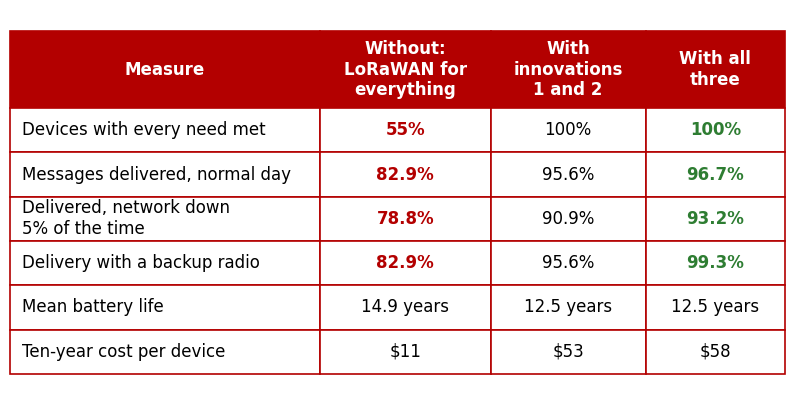

In [4]:
# ---- picture of the table in the red theme (fixed spacing)
RED, GREEN = '#b30000', '#2e7d32'
headers = ['Measure', 'Without:\nLoRaWAN for\neverything', 'With\ninnovations\n1 and 2', 'With all\nthree']
measures = ['Devices with every need met', 'Messages delivered, normal day', 'Delivered, network down\n5% of the time',
            'Delivery with a backup radio', 'Mean battery life', 'Ten-year cost per device']
cells = [[m] + list(table.iloc[i]) for i, m in enumerate(measures)]

fig, ax = plt.subplots(figsize=(10, 5)); ax.axis('off')
tb = ax.table(cellText=cells, colLabels=headers, loc='center', cellLoc='center',
              colWidths=[0.40, 0.22, 0.20, 0.18])
tb.auto_set_font_size(False); tb.set_fontsize(12)
for (r, c), cell in tb.get_celld().items():
    cell.set_edgecolor(RED); cell.set_linewidth(1.2)
    cell.set_height(0.20 if r == 0 else 0.115)            # tall header row for three lines of text
    if r == 0:
        cell.set_facecolor(RED); cell.get_text().set_color('white'); cell.get_text().set_fontweight('bold')
    elif c == 0:
        cell.get_text().set_ha('left'); cell.PAD = 0.04   # left-aligned measure names with a little padding
    elif c == 1 and r <= 4:
        cell.get_text().set_color(RED); cell.get_text().set_fontweight('bold')
    elif c == 3 and r <= 4:
        cell.get_text().set_color(GREEN); cell.get_text().set_fontweight('bold')
plt.savefig('results_table.png', dpi=200, bbox_inches='tight')
plt.show()

,Advantage,Measure,Without / single network,With CityMesh
0,Serves every device,Devices with every need met,55%,100%
1,More reliable,"Messages delivered, normal day",82.9%,96.7%
2,More reliable,Delivery with a backup link,82.9%,99.3%
3,Sustainable,Battery swaps in ten years,"275,000 (NB-IoT only)","33,000"
4,Affordable,Ten-year cost per device,$385 (5G only),$58
5,Faster response,Time to stop a leak (scenario),76 minutes,8 seconds


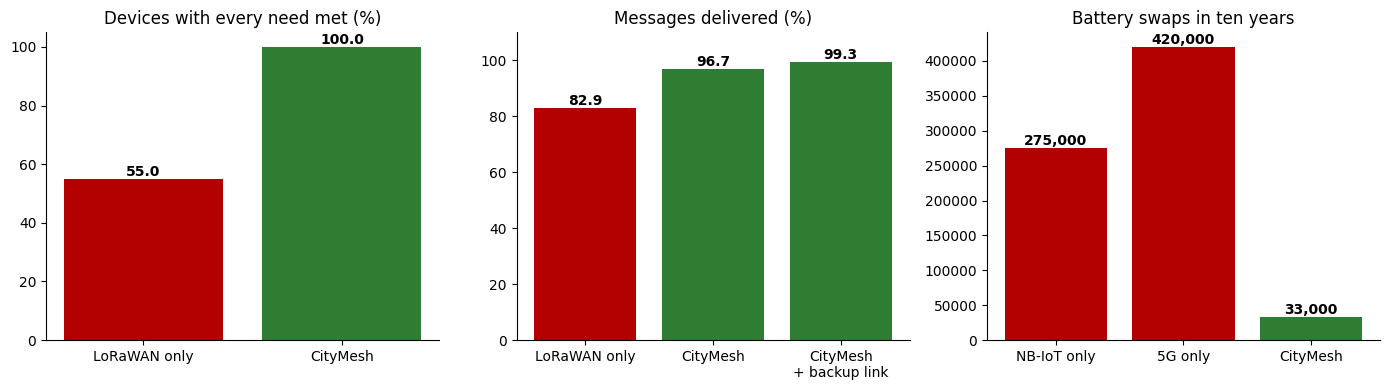

Water lost without: 91200 litres   with CityMesh: 160 litres


In [5]:
# ---- Simple EDA: the numbers behind each advantage
import pandas as pd
import matplotlib.pyplot as plt

R = run()
lora, nbiot, g5, mesh = R['single']['lora'], R['single']['nbiot'], R['single']['g5'], R['orch']

advantages = pd.DataFrame([
    ['Serves every device',   'Devices with every need met',      f"{lora['met']*100:.0f}%",   f"{mesh['met']*100:.0f}%"],
    ['More reliable',         'Messages delivered, normal day',   f"{lora['dl']*100:.1f}%",    f"{mesh['dl']*100:.1f}%"],
    ['More reliable',         'Delivery with a backup link',      f"{lora['alert']*100:.1f}%", f"{mesh['alert']*100:.1f}%"],
    ['Sustainable',           'Battery swaps in ten years',       f"{nbiot['swaps']:,.0f} (NB-IoT only)", f"{mesh['swaps']:,.0f}"],
    ['Affordable',            'Ten-year cost per device',         f"${g5['tco']:.0f} (5G only)", f"${mesh['tco']:.0f}"],
    ['Faster response',       'Time to stop a leak (scenario)',   '76 minutes',                '8 seconds'],
], columns=['Advantage', 'Measure', 'Without / single network', 'With CityMesh'])
display(advantages)

RED, GREEN = '#b30000', '#2e7d32'
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(['LoRaWAN only', 'CityMesh'], [lora['met']*100, mesh['met']*100], color=[RED, GREEN])
axes[0].set_title('Devices with every need met (%)')

axes[1].bar(['LoRaWAN only', 'CityMesh', 'CityMesh\n+ backup link'], [lora['dl']*100, mesh['dl']*100, mesh['alert']*100], color=[RED, GREEN, GREEN])
axes[1].set_title('Messages delivered (%)'); axes[1].set_ylim(0, 110)

axes[2].bar(['NB-IoT only', '5G only', 'CityMesh'], [nbiot['swaps'], g5['swaps'], mesh['swaps']], color=[RED, RED, GREEN])
axes[2].set_title('Battery swaps in ten years')

for ax in axes:
    for b in ax.patches:                                   # write the value on top of each bar
        ax.annotate(f'{b.get_height():,.0f}' if b.get_height() > 150 else f'{b.get_height():.1f}',
                    (b.get_x() + b.get_width() / 2, b.get_height()), ha='center', va='bottom', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig('advantages_eda.png', dpi=200); plt.show()

# Faster response: simple arithmetic from the pipe-burst scenario (20 litres per second leak)
print('Water lost without:', 20 * 76 * 60, 'litres   with CityMesh:', 20 * 8, 'litres')